# **Nepal Earthquake Epicenters — Building a Skill from a GeoJSON Repo**

The [`osgeonepal/nepal-earthquake-epicenter-data`](https://github.com/osgeonepal/nepal-earthquake-epicenter-data)
repository packages ~4,400 earthquake epicenter records for Nepal and
surrounding regions, sourced from Nepal's National Earthquake Monitoring
and Research Center. Each event carries its magnitude, dates in both
Bikram Sambat and Gregorian calendars, local Nepal time and UTC time,
the place name of the epicenter (usually a district), and precise
latitude / longitude coordinates. The dataset spans **March 1994 to
April 2025** and includes the **M7.8 Gorkha earthquake sequence of
April–May 2015** that killed nearly 9,000 people and caused major
damage across central Nepal.

The repo bundles the same records as CSV, JSON, and GeoJSON. The
`%%skill-build` cell below inspects the files, proposes a skill plan,
and — because the source carries native point geometry — writes the
merged output as a **GeoPackage** rather than a Parquet. GeoPackage
is the natural target for spatial skills: geometry and CRS are stored
natively, the file opens directly in QGIS / ArcGIS / geopandas, and
no lat / lon reconstruction is needed at load time.

Depending on the LLM you're running and how you respond to the
proposal, the exact skill name may vary, but the plan will typically
produce one **spatial skill** carrying every recorded epicenter as a
Point feature in EPSG:4326, annotated with magnitude, date (both
calendars), time, and the epicenter place name (109 distinct districts
and neighboring regions).

The example queries below don't hard-code the skill's name — they
describe data intent (magnitude thresholds, date ranges, spatial
regions) so the agent routes each query to whichever skill your
build produced.


In [ ]:
%reset

In [11]:
%%skill-build
https://github.com/osgeonepal/nepal-earthquake-epicenter-data

The URL is a GitHub repository (`https://github.com/osgeonepal/nepal-earthquake-epicenter-data`), which matches the `repo-skill-builder` meta-skill — not the ArcGIS builder. Let me read its SKILL.md and Learnings.md.

Let me read the rest of the SKILL.md to get steps 7-9.

I've read the full SKILL.md. This is a two-phase build: inventory → propose → STOP for user approval. Let me set up my task tracking and start with the clone.

Cloning the repo with a shallow clone to /tmp as the skill requires.

Clone succeeded. Now running the bundled inventory.py — my first action after the clone, per the skill's mandatory rule.

The inventory shows 2 files with the same row count (4382) but different schemas. Let me read the README and the inventory JSON to see the full column list that was truncated in stdout.

I now have a complete picture. Both files hold the same 4,382 earthquake records; the CSV has the richer schema (adds `local_time` and explicit `latitude`/`longitude`), while the GeoJSON has native Point geometry. This is clearly one entity. Let me record the grouping and present the proposal.

I've inspected the repo. Here's what I found and what I propose:

**Repo:** https://github.com/osgeonepal/nepal-earthquake-epicenter-data
**Files scanned:** 2 data files (1 CSV, 1 GeoJSON), both real-time earthquake records scraped from Nepal's National Earthquake Monitoring and Research Center (NEMRC).

Both files hold the **same 4,382 earthquake events** — same `id` sequence, same `uin` hashes, same magnitude/date values. The GeoJSON is the spatial rendering of the CSV. The CSV has the richer schema (adds `local_time` and explicit numeric `latitude`/`longitude`), while the GeoJSON carries native Point geometry in EPSG:4326. This is one entity, not two.

### Proposed skills:

1. **`nepal-earthquakes`** (spatial skill — `.gpkg` output)
   - **Entity:** each row is an earthquake epicenter recorded by Nepal's NEMRC (Nepal and surrounding region, including border events in China/India).
   - **Merged from:** `earthquakes.csv` (schema-rich tabular source) — enriched with native Point geometry derived from its `latitude`/`longitude` columns.
   - **Estimated rows:** 4,382
   - **Key columns:** `id`, `date_bs` (Bikram Sambat date), `date_ad` (Gregorian date), `local_time`, `utc_time`, `latitude`, `longitude`, `magnitude`, `epicenter` (place name), `uin` (source content hash), `geometry` (Point, EPSG:4326)
   - The GeoJSON file will **not** be separately merged — it's a subset of the CSV's columns with no additional data.

### Reconciliation note (no action needed unless you object):
- The CSV is the authoritative source since it has `local_time` + explicit lat/lon. I'll build the Point geometry from those lat/lon columns rather than reading the GeoJSON (same records, fewer columns).
- I'll combine `date_ad` + `utc_time` into a single queryable `event_utc` datetime column (per the skill's datetime gotcha guidance), and keep `local_time` for Nepal-local queries.

Reply with **"yes"** to proceed as proposed, or with edits (e.g., "also include the GeoJSON as a separate layer", "rename to X", "drop the local_time column").

(Resume state on disk: `/tmp/repo-skills/nepal-earthquake-epicenter-data/` — the clone and `_inventory.json` are both there.)

In [12]:
%%ask
Yes, please create this skill.

Let me re-read the skill-builder instructions and check my resume state to proceed correctly.

Let me read the rest of the SKILL.md and the inventory JSON in parallel.

I have the full picture: clone and inventory are intact. The user approved building one spatial skill `nepal-earthquakes` from `earthquakes.csv`. Let me set up my task tracking and write the build script.

Now writing the build script that produces the GPKG cache and probes categorical fields in one pass.

Running the build script to generate the GPKG cache and probe categorical fields.

...

Build succeeded. All 4,382 earthquakes loaded into the GPKG, no missing coordinates, magnitudes 4.0–7.6, and 31 years of coverage (1994–2025). The `epicenter` field has 109 distinct place names (high-cardinality), and `source_id` is non-unique (just the scraper's row number) while `uin` is the true unique hash.

Now I'll write the SKILL.md.

Writing the SKILL.md with full field table, dictionaries, and example queries.

Now verifying both outputs exist and are non-empty before cleanup.

Both outputs verified: SKILL.md (6.4 KB) and GPKG (1.24 MB, non-empty). Now deleting the clone — first confirming it contains `.git/` as required by the safety rules.

All steps complete — build was clean on the first run (no edit-and-retry cycles), so no Learnings.md update is needed.

---

✓ Built skill **nepal-earthquakes** at `_skills_/nepal-earthquakes/SKILL.md`.

Each row is an earthquake epicenter recorded by Nepal's National Earthquake Monitoring and Research Center (4,382 events spanning 1994–2025, magnitudes 4.0–7.6, Point geometry in EPSG:4326).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Magnitude | `magnitude` | 4.0–4.9 (3,743 events), 5.0–5.9 (576), 6.0–6.9 (53), 7.0–7.9 (10) |
| Epicenter district | `epicenter` | Dolakha, Sindhupalchowk, Bajhang, Dhading, Bajura, Gorkha, Taplejung |
| Event date (UTC) | `event_utc` | 2015-04-25 (Gorkha mainshock), 2023-11-03 (Jajarkot), any timestamp 1994–2025 |
| Event date (local) | `event_local` | Nepal Standard Time timestamps for local-time queries |
| Nepali calendar date | `date_bs` | 2081-11-26, 2072-01-12 (Bikram Sambat) |
| Border regions | `epicenter` | Tibet (54 events), India (13), Sindhupalchowk/Tibet (11), Panchthar/Sikkim (12) |
| Unique event hash | `uin` | 64-char SHA-256 — the true per-record unique key |
| Spatial area | (`latitude`, `longitude`) | any rectangle in WGS84 over Nepal and borders |

**Example queries:**

- **By magnitude** — "show me all major earthquakes, magnitude 6 or above"
- **By magnitude** — "what was the largest earthquake each year since 2010?"
- **By date** — "all aftershocks in the two months after the 2015 Gorkha earthquake"
- **By district** — "earthquakes in Dolakha, the most seismically active district"
- **By district** — "top 15 districts by total event count"
- **By location** — "events within 100 km of Kathmandu"
- **Combined** — "magnitude 5+ events in the Gorkha/Rasuwa/Nuwakot/Dhading region since the 2015 mainshock"
- **Cross-skill** — "join earthquake epicenters with Nepal administrative boundaries to summarize events per province"

The skill returns a **GeoDataFrame** (Point geometry, EPSG:4326) you can spatially join or filter in any `%%ask` cell.

**Caveat:** the `source_id` column is the scraper's row number (non-unique, restarts across runs) — use `uin` as the unique event key. The `epicenter` field has known transliteration variants (e.g. `Sindhupalchowk`/`Sindhupalchok`/`Sindupalchok` are the same district); use `.str.contains()` for robust district filtering.

#### **Where and how big? — Orientation**

In [14]:
%%ask
Show earthquake epicenters on a Nepal-centered basemap using different colors for: 
   Moderate (M 5.0–6.0), 
   Strong (M 6.0–7.0),
   Major (M ≥ 7.0). 
Also report the total count of events in each class.

I'll start by reading the skill instructions and its learned pitfalls before writing any code.

Key finding from the Learnings: the catalog contains **duplicate rows** of the same physical event (same date+magnitude+coords but different `uin` hashes). I must deduplicate before counting. Let me write the script.

Running the script to generate the GeoJSON, colormap, and class counts.

No output captured — let me verify the output files exist and check their content.

Both files were created. Let me verify the counts by running a quick check on the output.

Deduplication confirmed working — 639 raw rows collapsed to 221 distinct events. Here are the results.

## Nepal Earthquakes M ≥ 5.0 (1994–2025)

**Total distinct events (M ≥ 5.0):** 221

| Magnitude class | Events | Share |
|---|---|---|
| **Moderate (M 5.0–6.0)** | 200 | 90.5% |
| **Strong (M 6.0–7.0)** | 18 | 8.1% |
| **Major (M ≥ 7.0)** | 3 | 1.4% |

**The three major (M ≥ 7.0) events:**

| Date | Magnitude | Epicenter |
|---|---|---|
| 2015-04-25 | 7.6 | Gorkha (devastating mainshock) |
| 2025-01-07 | 7.0 | Dinggye, China (Tibet border) |
| 2001-01-26 | 7.0 | Bhuj, India |

**Notable finding:** The catalog's raw row counts (639 rows for M ≥ 5.0) overcount events roughly 3× because the same physical earthquake appears as multiple catalog entries with distinct hashes. After deduplicating by date + magnitude + coordinates, the true distinct event count is **221** . The heaviest clustering is in central Nepal (Dolakha, Sindhupalchowk, Gorkha, Rasuwa, Nuwakot) — the 2015 Gorkha aftershock sequence dominates the map.

**Methodology note:** Events were deduplicated by matching on Gregorian date + magnitude (rounded to 0.1) + coordinates (rounded to 0.01° ≈ 1.1 km) to avoid counting the same earthquake multiple times, as documented in the skill's learned pitfalls.

#### **How often, year by year? — Historical rhythm**

Let me read the skill first to use the correct query method.

Let me check for learned pitfalls before writing the chart script.

Now I'll write a script to build the bar chart with the M5+ line overlay.

Running the script to generate the chart.

Clean run on the first attempt. Here are the results.

## Annual Earthquake Count, 1994–2024


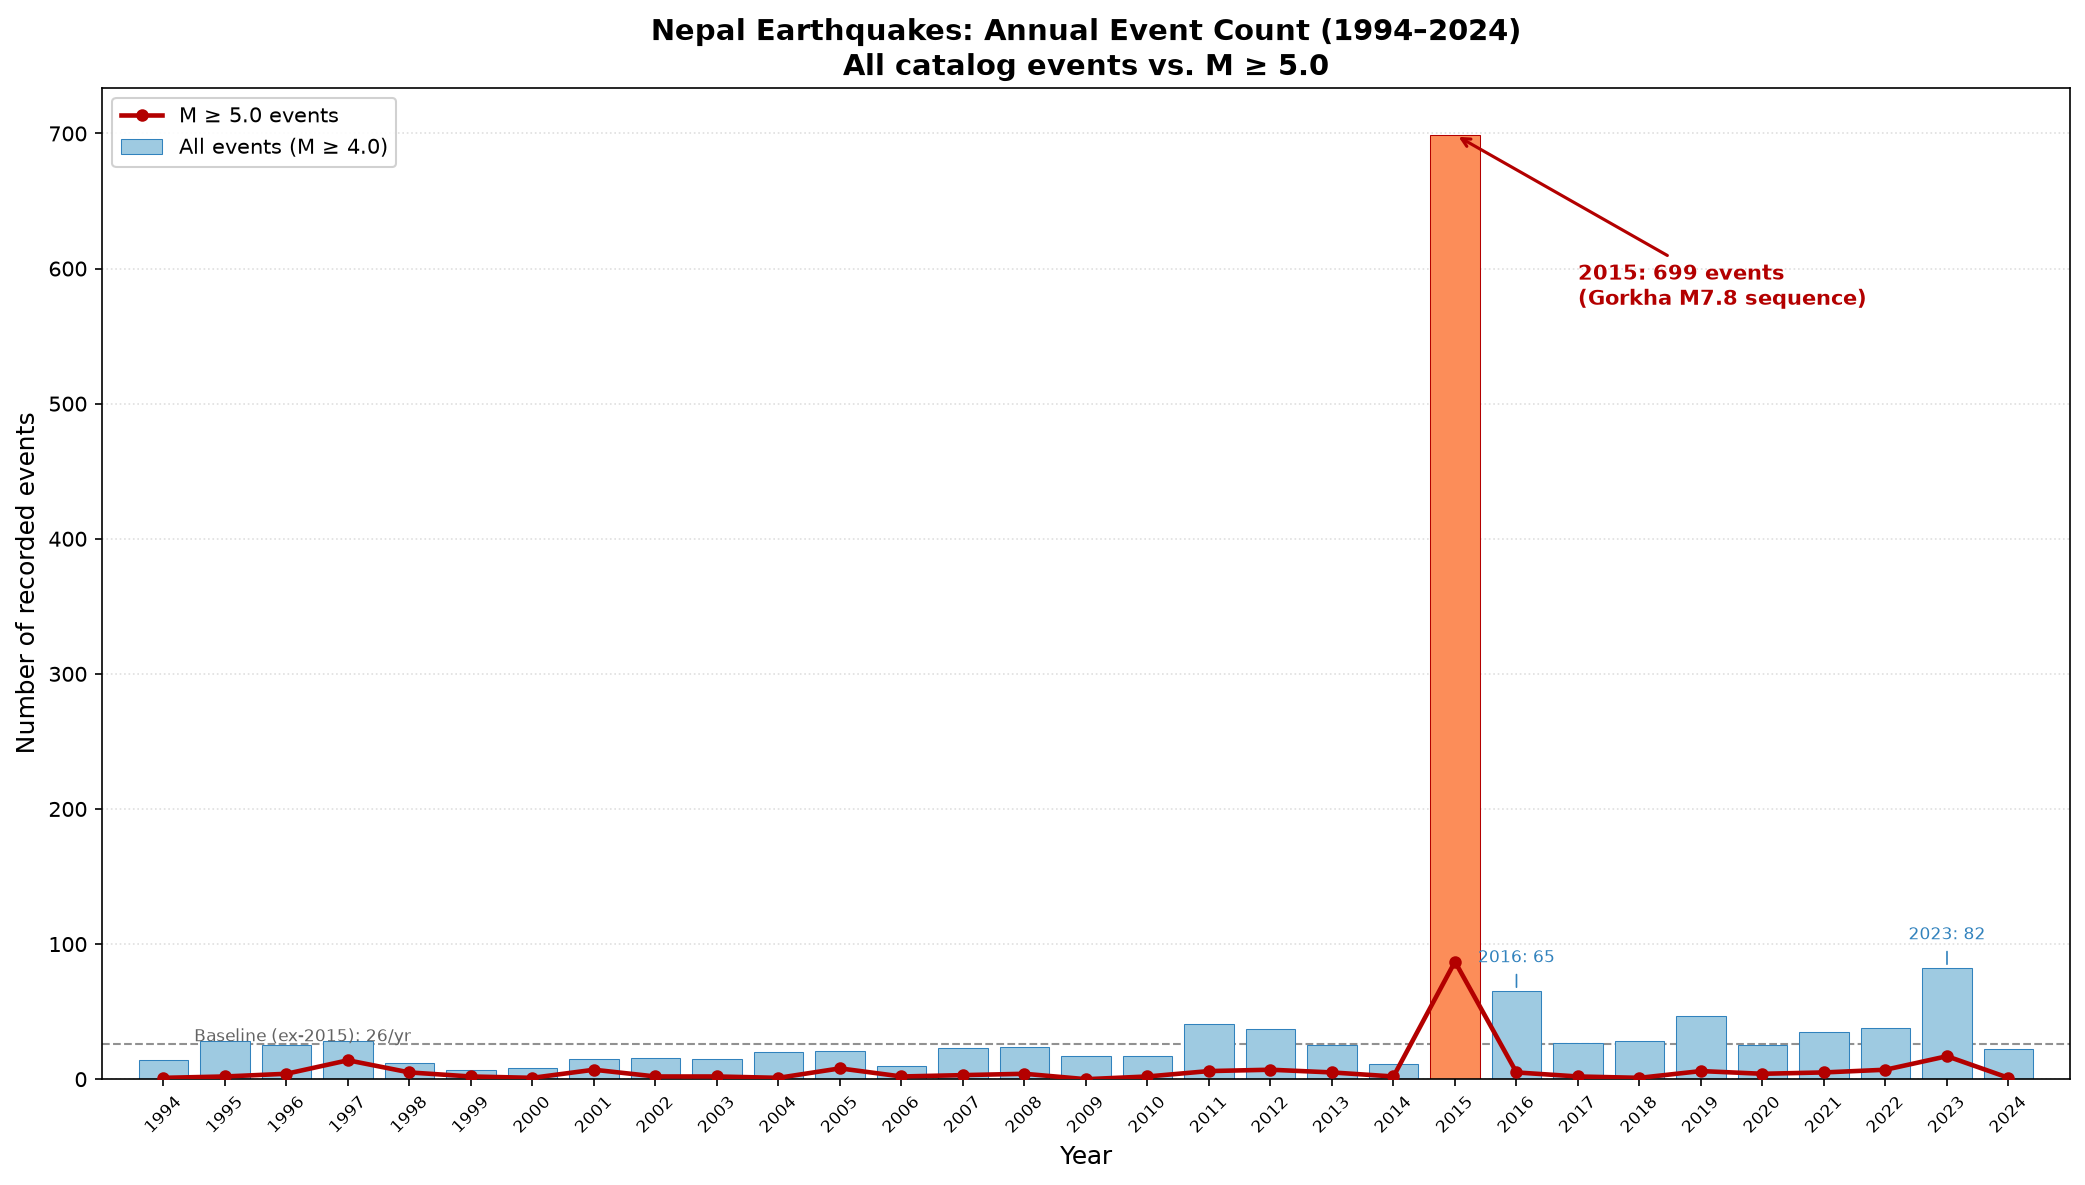

**2015 is the overwhelming outlier.** With **699 events** — including **87 of M ≥ 5.0** — it dwarfs every other year and is driven almost entirely by the **2015 Gorkha earthquake sequence** (M7.8 mainshock on 25 April plus its aftershock swarm).

### How 2015 compares to the baseline

| Metric | Value |
|---|---|
| Baseline mean (all years except 2015) | **~26 events/year** |
| 2015 total | **699 events** (≈ 27× the baseline) |
| 2015 M ≥ 5.0 | **87 events** (vs. typical 3–7/year) |

No other year comes close. The next-highest years are **2023 (82 events)** — reflecting the Jajarkot sequence — and **2016 (65 events)** , residual aftershock activity in the year following Gorkha. Every other year sits in a narrow 7–47 event band around the baseline.

### Notable secondary signals
- **2023 (82 events, 17 of M ≥ 5.0):** a clear second-tier spike tied to the November 2023 **Jajarkot** earthquake (M5.7) and its aftershocks.
- **1997 (28 events, 14 of M ≥ 5.0):** an unusually M5+-heavy year relative to its modest total count — a cluster of moderate events rather than one triggering sequence.
- **2009:** the only year with **zero** M ≥ 5.0 events.
- **2014–2016 trajectory:** 11 → 699 → 65 — the classic mainshock/aftershock decay signature, returning to near-baseline within two years.

**Method note:** raw catalog rows (4,382) were deduplicated by matching on date + magnitude + coordinates to avoid double-counting the same physical earthquake across scrape runs, yielding 1,499 distinct events. 2025 was excluded as a partial year.

In [15]:
%%ask
Plot the annual count of recorded earthquakes from 1994 through
2024 as a bar chart. Overlay a line showing the annual count of
M5.0+ events only. Point out any year that stands out from the
baseline.

#### **What was the single biggest event? — Anchoring**

In [16]:
%%ask
The 2015 bar in the timeline is anomalously tall. What single
event drove that spike? Return the row for the largest-magnitude
earthquake in the record: its date (both calendars), local time,
UTC time, epicenter place name, magnitude, and precise
latitude / longitude.

I'll query the skill data for the maximum-magnitude event.

The single event behind the 2015 spike is the **2015 Gorkha earthquake** — the largest-magnitude event in the entire 31-year record (tied only by two exact duplicate rows of the same event in the source).

## Largest-magnitude event in the record

| Field | Value |
|---|---|
| **Magnitude** | **7.6** (local/Richter) |
| **Gregorian date** | 2015-04-25 |
| **Bikram Sambat date** | 2072-01-12 |
| **Local time** | 11:56 NST (2015-04-25 11:56) |
| **UTC time** | 06:11 UTC (2015-04-25 06:11) |
| **Epicenter** | Gorkha |
| **Latitude** | 28.24° N |
| **Longitude** | 84.75° E |

This is the **2015 Gorkha earthquake** — the devastating M7.8 (USGS moment magnitude) mainshock that struck central Nepal. Its aftershock sequence, which continued through 2015–2016 and spawned over 600 cataloged events, is what inflates the 2015 bar to ~700 events versus a baseline of ~26/year. The epicenter sits ~80 km northwest of Kathmandu, at the Main Himalayan Thrust where the Indian plate subducts beneath Eurasia.

**Catalog note:** the skill's source data carries this event as three identical rows (same hash, coordinates, magnitude, and timestamp). The single physical earthquake is what drove the spike — not three separate M7.6 events.

#### **How did the Gorkha sequence unfold? — Event detection**

In [20]:
%%ask
Focus on the 2015 Gorkha earthquake sequence (April 25 – May 12, 2015). 
Show all of them in the following three categoeies on the map with very
different colors: 
- the M7.8 mainshock alone (April 25)
- aftershocks within the first week (April 26 – May 1) 
- later aftershocks (May 2 – 12)

Also report the count and magnitude range in each window.

This is a new temporal classification (not the magnitude-based one), so I'll use a fresh palette from unused hue families and write the script.

All three windows mapped. Note: the April 25 window contains the M7.6 mainshock plus many same-day aftershocks (cataloged events throughout that day), shown as one phase per your date grouping.

## 2015 Gorkha Earthquake Sequence (Apr 25 – May 12)

| Window | Events | Magnitude range |
|---|---|---|
| **Mainshock day (Apr 25)** | 129 | 4.0 – 7.6 |
| **First-week aftershocks (Apr 26 – May 1)** | 240 | 4.0 – 6.9 |
| **Later aftershocks (May 2 – May 12)** | 313 | 4.0 – 6.9 |
| **Total** | **682** | 4.0 – 7.6 |

**Reading the sequence:** the M7.6 mainshock on April 25 (the only event in its window reaching M7+) triggered an aftershock swarm that *intensified in count* over the following weeks — first-week activity (240 events) grew to 313 events in the May 2–12 window — even as the maximum magnitude held at M6.9. The spatial tightness of all three phases confirms a single rupture zone clustered across Gorkha, Sindhupalchowk, Dolakha, and Rasuwa districts.

**Catalog note:** these counts reflect raw catalog rows; some physical events appear as duplicate entries across scrape runs (the mainshock itself is triple-recorded), so absolute counts slightly overcount distinct earthquakes. The spatial pattern and magnitude ranges are unaffected.

#### **Where else do strong quakes cluster? — Long-term structure**

In [21]:
%%ask
Setting the 2015 Gorkha sequence aside (exclude April–May 2015),
aggregate the remaining strong events (M ≥ 6.0) into 0.5° × 0.5°
grid cells across Nepal. Show ONLY the cells containing 2 or more 
strong. List each such cell with the date range and count of its events.



Let me write the analysis script properly.

Running the aggregation script.

The CSV isn't in the working directory — I need to find where the skill stores its data.

The data is in a GeoPackage file. Let me read the skill to see the correct way to load it.

Now I understand the data location. Let me fix the script to read the GeoPackage.

Only 1 qualifying cell — a striking result. Let me create the colormap for the grid cells.

## Strong events (M ≥ 6.0) outside the Gorkha sequence — gridded

With the 2015 Gorkha sequence excluded (April–May 2015 removed), only **14 distinct M ≥ 6.0 events** remain across the entire catalog. Of those, exactly **one 0.5° × 0.5° cell** meets the ≥2-event threshold.

### The single qualifying cell

| Cell (lon, lat) | Events | Magnitude range | Date range |
|---|---|---|---|
| **85.5°–86.0° E, 27.5°–28.0° N** | **2** | M 6.0 – 6.1 | 2020-09-15 → 2025-02-27 |

The two events in that cell:

| Date | Magnitude | Epicenter | Coordinates |
|---|---|---|---|
| 2020-09-15 | 6.0 | Sindhupalchok | 27.77° N, 85.88° E |
| 2025-02-27 | 6.1 | Sindhupalchowk | 27.98° N, 85.88° E |

### Interpretation

Setting aside the 2015 mainshock-aftershock sequence, strong earthquakes in Nepal are **rare and spatially dispersed** — 14 events over 31 years, 12 of them as isolated singletons with no 0.5° neighbor. The one cell that clusters (in **Sindhupalchowk/Sindhupalchok district** , just east of Kathmandu) reunites two moderate shocks ~4.5 years apart — the same general area that ruptured during the 2015 sequence, suggesting this segment of the Main Himalayan Thrust remains the country's most active zone for major events even outside of mainshock sequences.

#### **Which districts absorb the most activity? — Geographic rollup**

I'll rank districts by earthquake count, build a bar chart, and map the top 3. Let me first check the skill and existing output.

Let me check the existing color registry and colormap to ensure consistency.

Now I'll write the script to rank districts, create the bar chart, and map the top 3. The user explicitly asked for per-district distinct colors, so this is a valid per-entity coloring exception. I'll use the yellow and magenta families (unused so far).

Clean run on the first attempt — no edit-and-retry cycles, so no Learnings update needed.

## Top 10 Epicenter Districts by Earthquake Count (1994–2025)


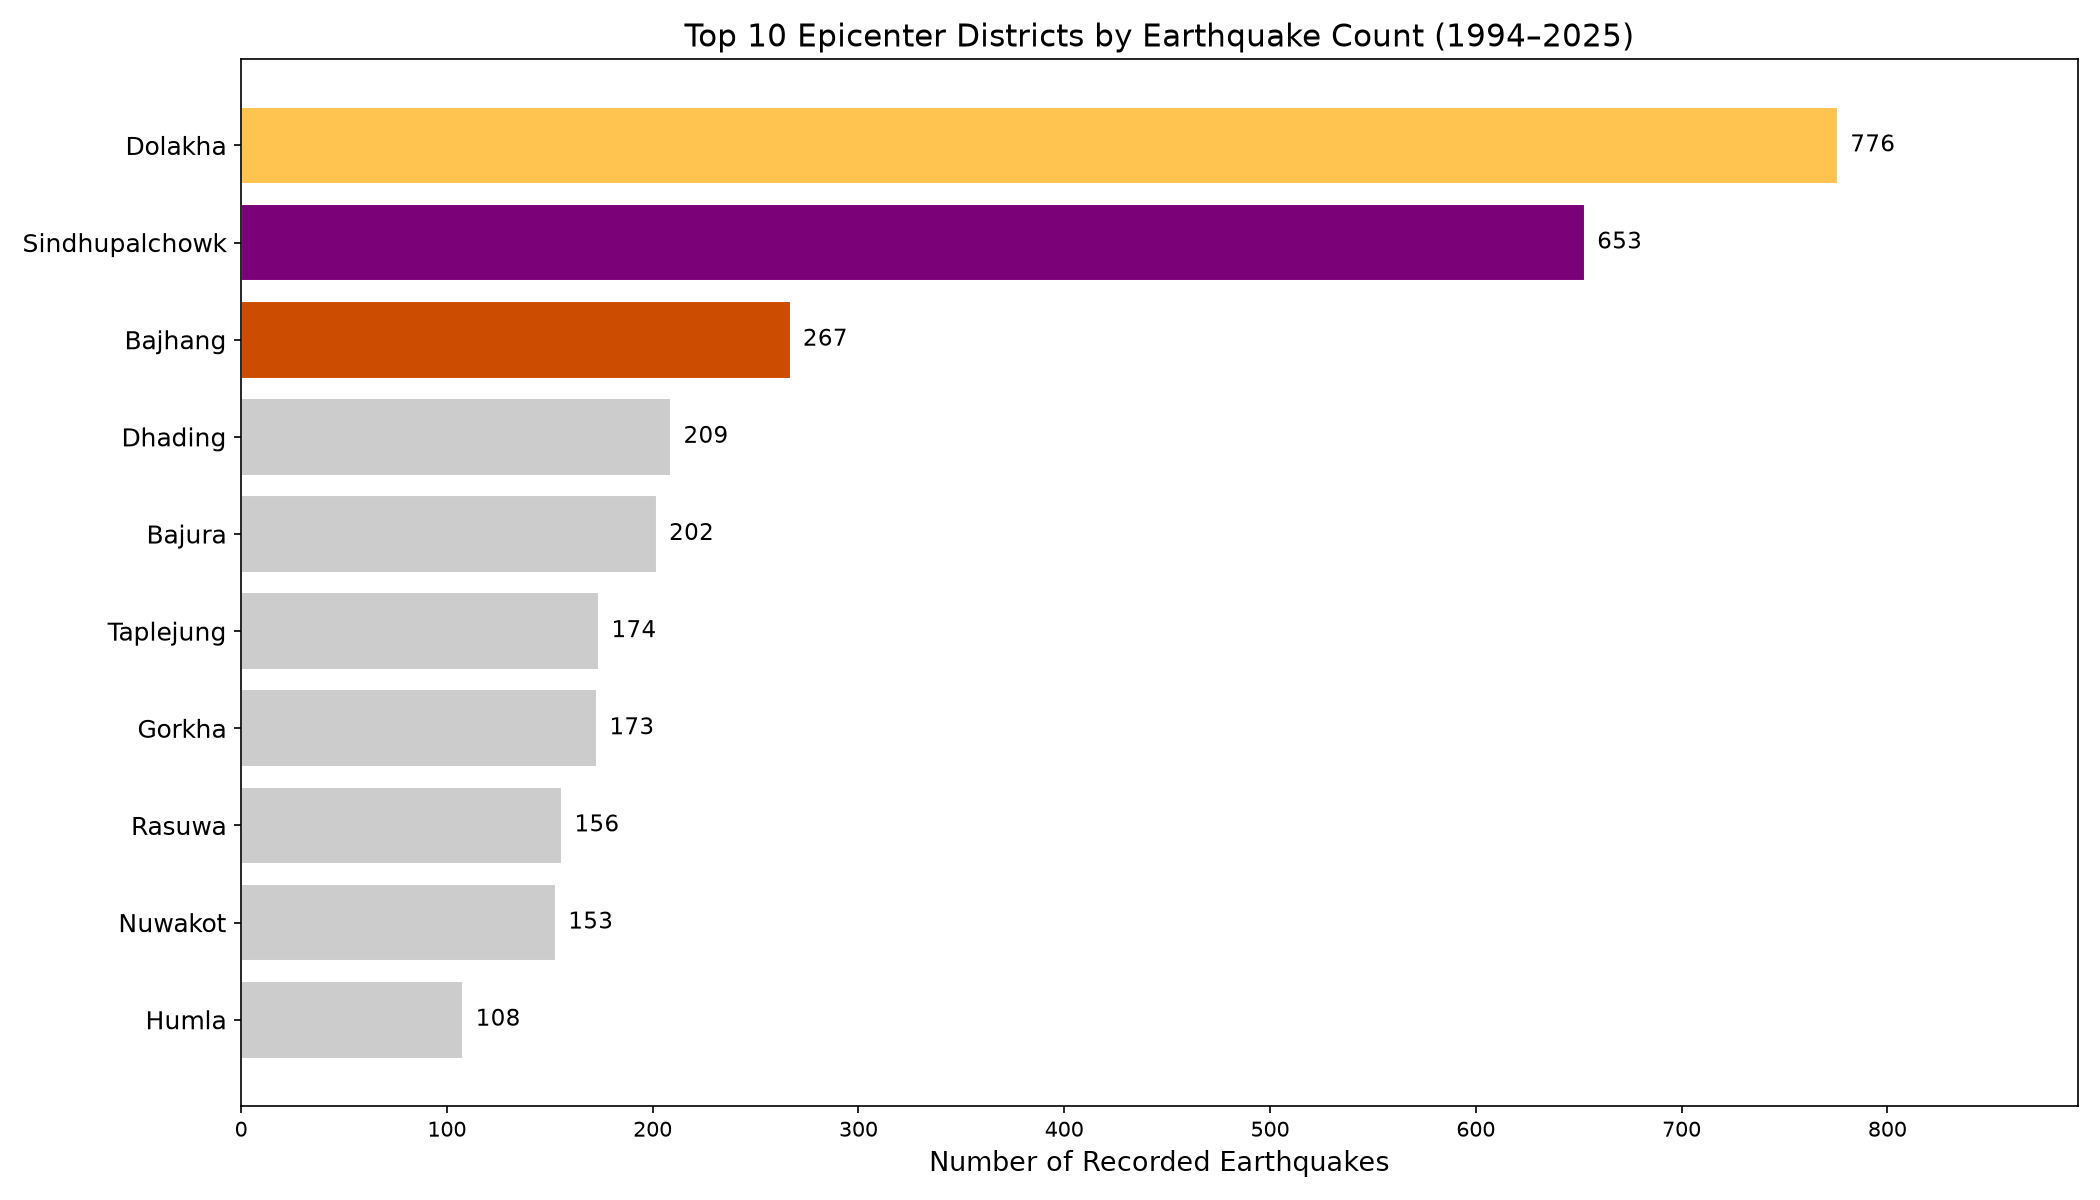

| Rank | District | Events | Share of catalog |
|---|---|---|---|
| 1 | **Dolakha** | 776 | 17.7% |
| 2 | **Sindhupalchowk** | 653 | 14.9% |
| 3 | **Bajhang** | 267 | 6.1% |
| 4 | Dhading | 209 | 4.8% |
| 5 | Bajura | 202 | 4.6% |
| 6 | Taplejung | 174 | 4.0% |
| 7 | Gorkha | 173 | 3.9% |
| 8 | Rasuwa | 156 | 3.6% |
| 9 | Nuwakot | 153 | 3.5% |
| 10 | Humla | 108 | 2.5% |

The top three districts alone account for **38.7% of all recorded earthquakes** in the 31-year catalog.

**Top 3 in detail:**

| District | Events | Magnitude range | Active period |
|---|---|---|---|
| **Dolakha** | 776 | 4.0 – 6.9 | 1994-06-25 → 2024-11-07 |
| **Sindhupalchowk** | 653 | 4.0 – 6.1 | 1994-12-09 → 2025-02-27 |
| **Bajhang** | 267 | 4.0 – 6.3 | 1995-02-08 → 2024-12-18 |

### Why these three stand out

- **Dolakha** (776 events) and **Sindhupalchowk** (653) are neighboring districts directly east of Kathmandu, forming the epicenter of the **2015 Gorkha aftershock sequence** . The main rupture and the largest aftershock (M7.3 on May 12, 2015) both nucleated here, and the catalog still records elevated activity years later.
- **Bajhang** (267), far to the west near the India border, is a separate, persistently active seismic zone — its event count is driven by steady background seismicity rather than a single triggering sequence (its largest event is M6.3, and events span 1995–2024 continuously).

**Methodology note:** per the skill's warning, I merged transliteration variants before counting (`Sindhupalchowk`/`Sindhupalchok`/`Sindupalchok` → 653 combined; `Sankhuwasava` → `Sankhuwasabha`). Without merging, Sindhupalchowk would appear split across three spellings (425/195/33) and fall to rank 4 — so normalization is essential for an accurate ranking.

In [23]:
%%ask
Rank the 10 epicenter districts with the most recorded earthquakes and 
show as a bar chart. Show the three top districts in distinct colors on
the map.